# **Dataset Heart Dissease: https://drive.google.com/file/d/1oGsM9EAFWiE28jDXT1IKhWwsqzIOcXcN/view**

In [ ]:
!gdown 1oGsM9EAFWiE28jDXT1IKhWwsqzIOcXcN

Downloading...
From: https://drive.google.com/uc?id=1oGsM9EAFWiE28jDXT1IKhWwsqzIOcXcN
To: /content/cleveland.csv
100% 10.9k/10.9k [00:00<00:00, 28.5MB/s]


# **Bài tập 1**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/cleveland.csv", header = None)
df.columns = ['age', 'sex', 'cp', 'trestbps', 'chol',
              'fbs', 'restecg', 'thalach', 'exang',
              'oldpeak', 'slope', 'ca', 'thal', 'target']
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,1,110,264,0,0,132,0,1.2,2,0.0,7.0,1
299,68,1,4,144,193,1,0,141,0,3.4,2,2.0,7.0,2
300,57,1,4,130,131,0,0,115,1,1.2,2,1.0,7.0,3
301,57,0,2,130,236,0,2,174,0,0.0,2,1.0,3.0,1


In [ ]:
df.isna().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
df['target'] = df.target.map({0: 0, 1: 1, 2: 1, 3: 1, 4: 1})
df['thal'] = df.thal.fillna(df.thal.mean())
df['ca'] = df.ca.fillna(df.ca.mean())

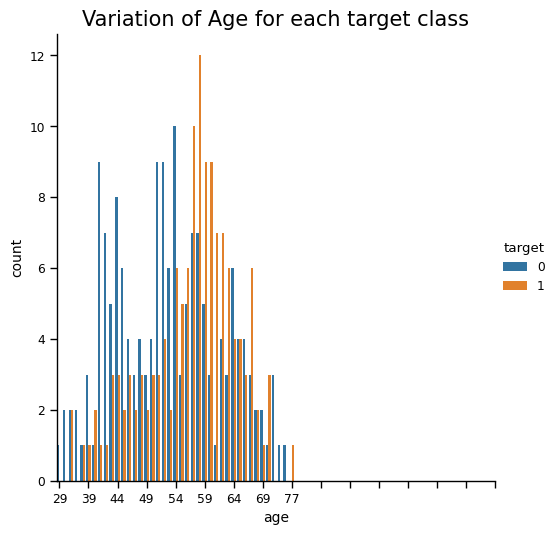

In [ ]:
# Distribution of target vs age
sns.set_context("paper", font_scale = 1, rc = {"font.size": 3, "axes.titlesize": 15, "axes.labelsize": 10})
ax = sns.catplot(kind = 'count', data = df, x = 'age', hue = 'target', order = df['age'].sort_values().unique())
ax.ax.set_xticks(np.arange(0, 80, 5))
plt.title('Variation of Age for each target class')
plt.show()

# **Bài tập 2**

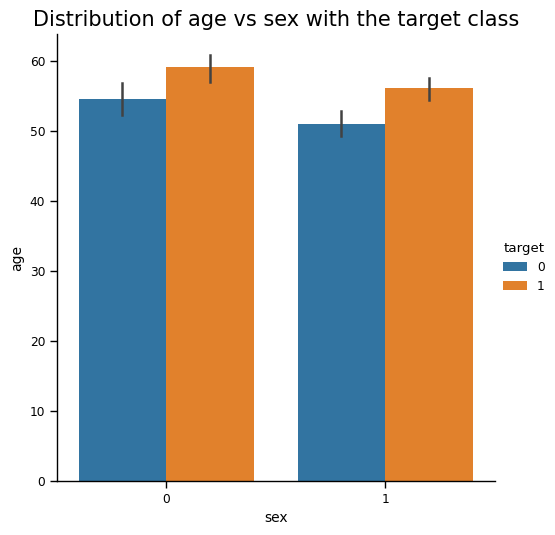

In [ ]:
# barplot of age vs sex with hue = target
sns.catplot(kind = 'bar', data = df, y = 'age', x = 'sex', hue = 'target')
plt.title('Distribution of age vs sex with the target class')
plt.show()

# **Bài tập 3**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42
)

classifier = KNeighborsClassifier(n_neighbors = 5, weights = 'uniform',
                                  algorithm= 'auto',
                                  leaf_size = 30,
                                  p = 2, metric = 'minkowski')

classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
cm_test = confusion_matrix(y_pred, y_test)

y_pred_train = classifier.predict(X_train)
cm_train = confusion_matrix(y_pred_train, y_train)

print()
accuracy_for_train = np.round((cm_train[0][0] + cm_train[1][1]) / len(y_train), 2)
accuracy_for_test = np.round((cm_test[0][0] + cm_test[1][1]) / len(y_test), 2)
print("Accuracy for training set for KNeiborClassifier = {}".format(
    accuracy_for_train
))
print("Accuracy for test set for KNeiborClassifier = {}".format(
    accuracy_for_test
))


Accuracy for training set for KNeiborClassifier = 0.76
Accuracy for test set for KNeiborClassifier = 0.69


# **Bài Tập 4**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42
)

classifier = SVC(kernel = 'rbf', random_state = 42)
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)
cm_test = confusion_matrix(y_pred, y_test)

y_pred_train = classifier.predict(X_train)
cm_train = confusion_matrix(y_pred_train, y_train)

print()
accuracy_for_train = np.round((cm_train[0][0] + cm_train[1][1]) / len(y_train), 2)
accuracy_for_test = np.round((cm_test[0][0] + cm_test[1][1]) / len(y_test), 2)
print("Accuracy for training set for SVM = {}".format(
    accuracy_for_train
))
print("Accuracy for test set for SVM = {}".format(
    accuracy_for_test
))


Accuracy for training set for SVM = 0.66
Accuracy for test set for SVM = 0.67


# **Bài tập 5**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42
)

classifier = GaussianNB()
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)
cm_test = confusion_matrix(y_pred, y_test)

y_pred_train = classifier.predict(X_train)
cm_train = confusion_matrix(y_pred_train, y_train)

print()
accuracy_for_train = np.round((cm_train[0][0] + cm_train[1][1]) / len(y_train), 2)
accuracy_for_test = np.round((cm_test[0][0] + cm_test[1][1]) / len(y_test), 2)
print("Accuracy for training set for GaussianNB = {}".format(
    accuracy_for_train
))
print("Accuracy for test set for GaussianNB = {}".format(
    accuracy_for_test
))


Accuracy for training set for GaussianNB = 0.85
Accuracy for test set for GaussianNB = 0.84


# **Bài tập 6**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42
)

classifier = DecisionTreeClassifier(criterion='gini', max_depth=10, min_samples_split = 2)
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)
cm_test = confusion_matrix(y_pred, y_test)

y_pred_train = classifier.predict(X_train)
cm_train = confusion_matrix(y_pred_train, y_train)

print()
accuracy_for_train = np.round((cm_train[0][0] + cm_train[1][1]) / len(y_train), 2)
accuracy_for_test = np.round((cm_test[0][0] + cm_test[1][1]) / len(y_test), 2)
print("Accuracy for training set for Decision Tree = {}".format(
    accuracy_for_train
))
print("Accuracy for test set for Decision Tree = {}".format(
    accuracy_for_test
))


Accuracy for training set for Decision Tree = 1.0
Accuracy for test set for Decision Tree = 0.74


# **Bài tập 7**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42
)

classifier = RandomForestClassifier(criterion='gini', max_depth=10, min_samples_split = 2,
                                    n_estimators = 10, random_state = 42)
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)
cm_test = confusion_matrix(y_pred, y_test)

y_pred_train = classifier.predict(X_train)
cm_train = confusion_matrix(y_pred_train, y_train)

print()
accuracy_for_train = np.round((cm_train[0][0] + cm_train[1][1]) / len(y_train), 2)
accuracy_for_test = np.round((cm_test[0][0] + cm_test[1][1]) / len(y_test), 2)
print("Accuracy for training set for RandomForest Classifier = {}".format(
    accuracy_for_train
))
print("Accuracy for test set for RandomForest Classifier = {}".format(
    accuracy_for_test
))


Accuracy for training set for RandomForest Classifier = 0.98
Accuracy for test set for RandomForest Classifier = 0.8


# **Bài tập 8**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import confusion_matrix

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42
)

classifier = AdaBoostClassifier(n_estimators = 50, learning_rate = 1.0, random_state = 42)
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)
cm_test = confusion_matrix(y_pred, y_test)

y_pred_train = classifier.predict(X_train)
cm_train = confusion_matrix(y_pred_train, y_train)

print()
accuracy_for_train = np.round((cm_train[0][0] + cm_train[1][1]) / len(y_train), 2)
accuracy_for_test = np.round((cm_test[0][0] + cm_test[1][1]) / len(y_test), 2)
print("Accuracy for training set for AdaBoost = {}".format(
    accuracy_for_train
))
print("Accuracy for test set for AdaBoost = {}".format(
    accuracy_for_test
))


Accuracy for training set for AdaBoost = 0.88
Accuracy for test set for AdaBoost = 0.9


# **Bài tập 9**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42
)

classifier = GradientBoostingClassifier(learning_rate = 0.1, n_estimators = 100,
                                        subsample = 1.0, min_samples_split = 2,
                                        max_depth = 3, random_state = 42)
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)
cm_test = confusion_matrix(y_pred, y_test)

y_pred_train = classifier.predict(X_train)
cm_train = confusion_matrix(y_pred_train, y_train)

print()
accuracy_for_train = np.round((cm_train[0][0] + cm_train[1][1]) / len(y_train), 2)
accuracy_for_test = np.round((cm_test[0][0] + cm_test[1][1]) / len(y_test), 2)
print("Accuracy for training set for Gradient Boosting = {}".format(
    accuracy_for_train
))
print("Accuracy for test set for Gradient Boosting = {}".format(
    accuracy_for_test
))


Accuracy for training set for Gradient Boosting = 1.0
Accuracy for test set for Gradient Boosting = 0.85


# **Bài tập 10**

In [ ]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42
)

classifier = XGBClassifier(objective="binary:logistic", random_state=42, n_estimators = 100)
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)
cm_test = confusion_matrix(y_pred, y_test)

y_pred_train = classifier.predict(X_train)
cm_train = confusion_matrix(y_pred_train, y_train)

print()
accuracy_for_train = np.round((cm_train[0][0] + cm_train[1][1]) / len(y_train), 2)
accuracy_for_test = np.round((cm_test[0][0] + cm_test[1][1]) / len(y_test), 2)
print("Accuracy for training set for XGBoost = {}".format(
    accuracy_for_train
))
print("Accuracy for test set for XGBoost = {}".format(
    accuracy_for_test
))


Accuracy for training set for XGBoost = 1.0
Accuracy for test set for XGBoost = 0.87


# **Bài tập 11**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import confusion_matrix

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42
)

dtc = DecisionTreeClassifier(random_state = 42)
rfc = RandomForestClassifier(random_state = 42)
knn = KNeighborsClassifier()
xgb = XGBClassifier(XGBClassifier)
gc = GradientBoostingClassifier(random_state = 42)
svc = SVC(kernel = 'rbf', random_state = 42)
ad = AdaBoostClassifier(random_state = 42)

clf = [('dtc', dtc), ('rfc', rfc), ('knn', knn), ('gc', gc), ('ad', ad), ('svc', svc)]
xg = XGBClassifier()
classifier = StackingClassifier(estimators = clf, final_estimator = xg)
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

cm_test = confusion_matrix(y_pred, y_test)

y_pred_train = classifier.predict(X_train)
cm_train = confusion_matrix(y_pred_train, y_train)

print()
accuracy_for_train = np.round((cm_train[0][0] + cm_train[1][1]) / len(y_train), 2)
accuracy_for_test = np.round((cm_test[0][0] + cm_test[1][1]) / len(y_test), 2)
print("Accuracy for training set for Stacking Classifier = {}".format(
    accuracy_for_train
))
print("Accuracy for test set for Stacking Classifier = {}".format(
    accuracy_for_test
))

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:550: FutureWarning: Pass `objective` as keyword args.
  warnings.warn(msg, FutureWarning)



Accuracy for training set for Stacking Classifier = 0.88
Accuracy for test set for Stacking Classifier = 0.87
